# HRM Melt-Curve Classification of Bacterial Species

**At a glance**
- **Task:** identify 10 bacterial species (10 classes) from digital high-resolution melt (dHRM) curves
- **Model:** Random Forest (scikit-learn, 200 trees); baselines in section 10
- **Data:** 18,281 melt curves, 160 points each (0.1 °C steps), from Langouche et al., *Bioinformatics* 2020 (see README for the link)
- **Split:** stratified random 80/20 split of *individual curves* (14,624 train / 3,657 test), plus 5-fold CV in section 10
- **Scope of the claim:** the score measures how well curves are discriminated *within this dataset*. According to the dataset paper, each species' curves come from a single chip, so species and chip/run are confounded. Generalisation to new chips, instruments or datasets is **not** tested here (see section 11).

**Pipeline:** load data → class overview → visualise melt curves → peak-temperature summary → duplicate check → train/test split → Random Forest → evaluation → robustness checks

**Data format:** `0.csv` … `9.csv` (one file per species). Each row is one smoothed melt curve (−dF/dT, per the dataset paper); the 160 columns are signal values at increasing temperature. The first column in each file is a sample index and is dropped.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load data
Each file `i.csv` becomes class `i`.

In [23]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

dfs = []

for i in range(10):
    temp = pd.read_csv(f"{i}.csv").copy()
    temp["label"] = i
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Separate features and labels
X = df.drop(columns=["label"])
y = df["label"]

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)
print("Number of classes:", y.nunique())

print("\nClass distribution:")
print(y.value_counts().sort_index())

Dataset shape: (18281, 161)
Feature shape: (18281, 160)
Number of classes: 10

Class distribution:
label
0    2052
1     843
2    1137
3    2249
4    2265
5    2244
6    2028
7    2006
8    2202
9    1255
Name: count, dtype: int64


## 3. Class overview

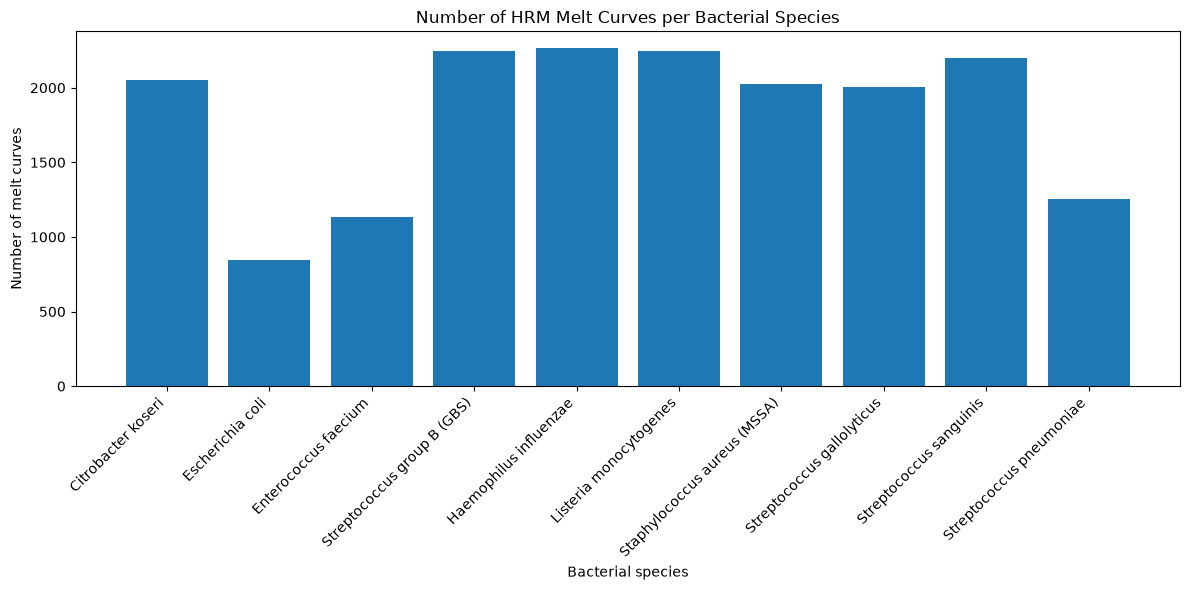

In [3]:
species_names = {
    0: "Citrobacter koseri",
    1: "Escherichia coli",
    2: "Enterococcus faecium",
    3: "Streptococcus group B (GBS)",
    4: "Haemophilus influenzae",
    5: "Listeria monocytogenes",
    6: "Staphylococcus aureus (MSSA)",
    7: "Streptococcus gallolyticus",
    8: "Streptococcus sanguinis",
    9: "Streptococcus pneumoniae"
}

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.bar(
    [species_names[i] for i in range(10)],
    [class_counts[i] for i in range(10)]
)

plt.xlabel("Bacterial species")
plt.ylabel("Number of melt curves")
plt.title("Number of HRM Melt Curves per Bacterial Species")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Representative melt curves
Median curve per species.

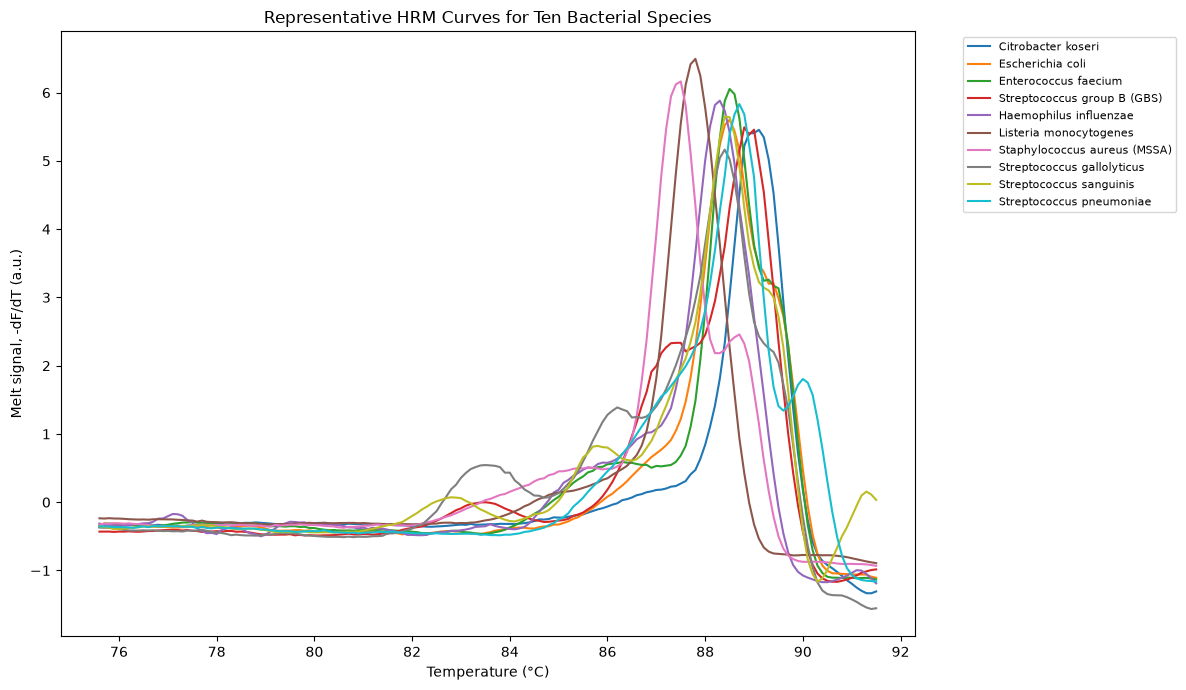

In [4]:
plt.figure(figsize=(12, 7))

for label in range(10):

    class_data = X[y == label]

    # Select one representative curve: median curve
    representative_curve = class_data.median(axis=0)

    temperatures = X.columns.astype(float)

    plt.plot(
        temperatures,
        representative_curve,
        label=species_names[label]
    )

plt.xlabel("Temperature (°C)")
plt.ylabel("Melt signal, -dF/dT (a.u.)")
plt.title("Representative HRM Curves for Ten Bacterial Species")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

## 5. Peak melting temperature by species
The peak temperatures, amplicon lengths and DTW values below are **copied from Table 1 of Langouche et al. (2020)**; they are not computed in this notebook.

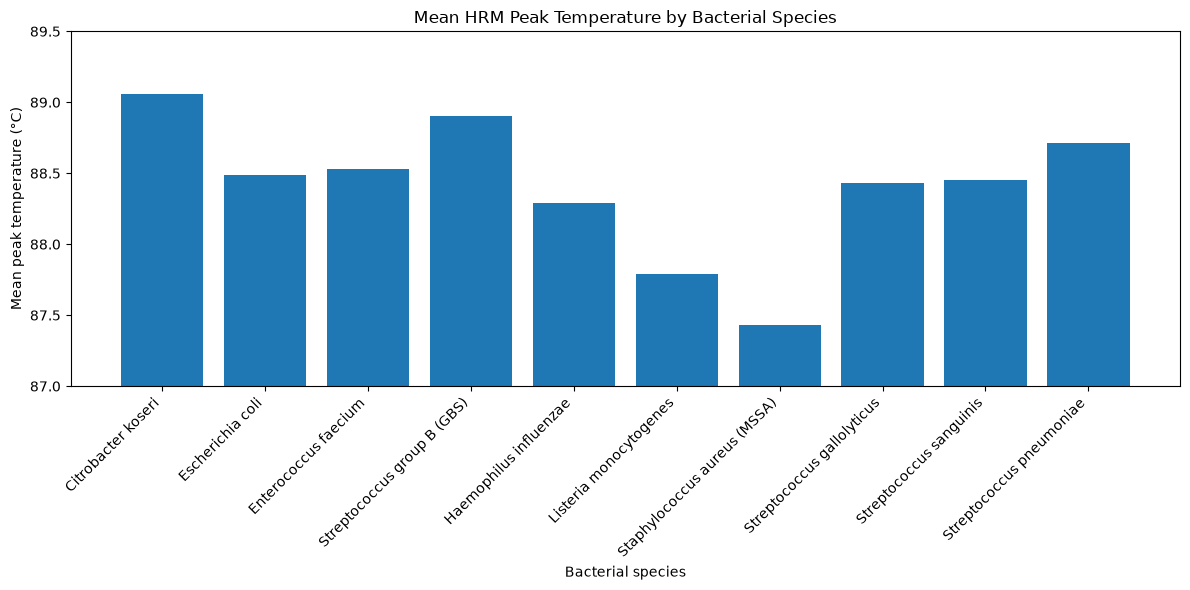

In [5]:
mean_peak = {
    "Citrobacter koseri": 89.06,
    "Escherichia coli": 88.49,
    "Enterococcus faecium": 88.53,
    "Streptococcus group B (GBS)": 88.90,
    "Haemophilus influenzae": 88.29,
    "Listeria monocytogenes": 87.79,
    "Staphylococcus aureus (MSSA)": 87.43,
    "Streptococcus gallolyticus": 88.43,
    "Streptococcus sanguinis": 88.45,
    "Streptococcus pneumoniae": 88.71
}

plt.figure(figsize=(12, 6))

plt.bar(
    mean_peak.keys(),
    mean_peak.values()
)

plt.xlabel("Bacterial species")
plt.ylabel("Mean peak temperature (°C)")
plt.title("Mean HRM Peak Temperature by Bacterial Species")

plt.xticks(rotation=45, ha="right")

# Zoom in on the temperature range
plt.ylim(87.0, 89.5)

plt.tight_layout()
plt.show()

In [7]:
summary = pd.DataFrame({
    "Bacterial species": [
        "Citrobacter koseri",
        "Enterococcus faecium",
        "Escherichia coli",
        "Haemophilus influenzae",
        "Listeria monocytogenes",
        "Staphylococcus aureus (MSSA)",
        "Streptococcus gallolyticus",
        "Streptococcus group B (GBS)",
        "Streptococcus pneumoniae",
        "Streptococcus sanguinis"
    ],

    "Amplicon length (bp)": [
        969, 978, 981, 967, 994,
        981, 978, 978, 978, 972
    ],

    "Melt curves (n)": [
        2052, 1137, 843, 2265, 2244,
        2028, 2006, 2249, 1255, 2202
    ],

    "Mean peak (°C)": [
        89.06, 88.53, 88.49, 88.29, 87.79,
        87.43, 88.43, 88.90, 88.71, 88.45
    ],

    "Std. peak (°C)": [
        0.42, 0.10, 0.13, 0.10, 0.08,
        0.19, 0.78, 0.10, 0.15, 0.09
    ],

    "Median DTW": [
        2.31, 1.68, 2.60, 2.14, 2.23,
        1.51, 3.83, 2.37, 1.62, 3.00
    ]
})

print(summary.to_string(index=False))

           Bacterial species  Amplicon length (bp)  Melt curves (n)  Mean peak (°C)  Std. peak (°C)  Median DTW
          Citrobacter koseri                   969             2052           89.06            0.42        2.31
        Enterococcus faecium                   978             1137           88.53            0.10        1.68
            Escherichia coli                   981              843           88.49            0.13        2.60
      Haemophilus influenzae                   967             2265           88.29            0.10        2.14
      Listeria monocytogenes                   994             2244           87.79            0.08        2.23
Staphylococcus aureus (MSSA)                   981             2028           87.43            0.19        1.51
  Streptococcus gallolyticus                   978             2006           88.43            0.78        3.83
 Streptococcus group B (GBS)                   978             2249           88.90            0.10     

## 6. Sanity check: duplicate curves
Identical curves in both train and test sets would inflate accuracy.

In [8]:
n_dup = X.duplicated().sum()
print("Duplicate feature rows:", n_dup)

duplicates = df[X.duplicated(keep=False)]
print("Rows involved in duplicate curves:", len(duplicates))

duplicate_groups = df.groupby(list(X.columns))["label"].nunique()
print("Duplicate curves with different labels:", (duplicate_groups > 1).sum())

Duplicate feature rows: 0
Rows involved in duplicate curves: 0
Duplicate curves with different labels: 0


## 7. Train / test split
80/20 stratified split.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 14624
Testing samples: 3657
Features: 160


## 8. Train Random Forest

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 9. Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Accuracy: 0.9962
Macro F1-score: 0.9952
Weighted F1-score: 0.9962


In [13]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[species_names[i] for i in range(10)],
    digits=3
)

print(report)

                              precision    recall  f1-score   support

          Citrobacter koseri      0.993     0.990     0.991       410
            Escherichia coli      0.994     0.982     0.988       169
        Enterococcus faecium      0.983     0.991     0.987       227
 Streptococcus group B (GBS)      1.000     1.000     1.000       450
      Haemophilus influenzae      0.991     1.000     0.996       453
      Listeria monocytogenes      1.000     1.000     1.000       449
Staphylococcus aureus (MSSA)      0.998     0.993     0.995       406
  Streptococcus gallolyticus      1.000     1.000     1.000       401
     Streptococcus sanguinis      1.000     0.998     0.999       441
    Streptococcus pneumoniae      0.996     0.996     0.996       251

                    accuracy                          0.996      3657
                   macro avg      0.995     0.995     0.995      3657
                weighted avg      0.996     0.996     0.996      3657



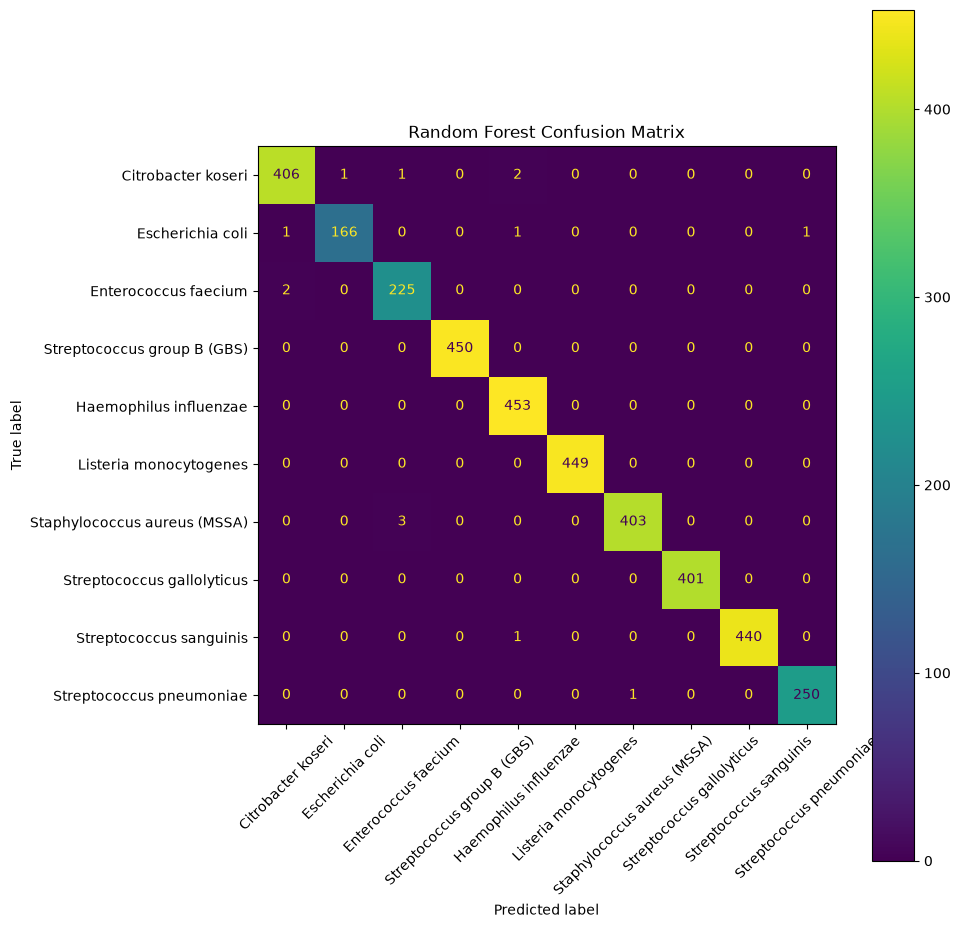

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[species_names[i] for i in range(10)]
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Robustness checks
Three checks that a single train/test split cannot give:
1. **5-fold stratified cross-validation:** is the score stable across different splits?
2. **Baselines:** how much better is the Random Forest than a trivial model and than 1-nearest-neighbour (Euclidean)?
3. **Shuffled-label control:** if the training labels are shuffled, accuracy should fall to chance. If it does not, something in the pipeline is leaking.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Majority class (dummy)": DummyClassifier(strategy="most_frequent"),
    "1-NN (Euclidean)": KNeighborsClassifier(n_neighbors=1, n_jobs=-1),
    "Random Forest (200 trees)": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
}

rows = []
for name, clf in models.items():
    res = cross_validate(
        clf, X, y, cv=skf,
        scoring={"acc": "accuracy", "f1": "f1_macro"}
    )
    rows.append({
        "Model": name,
        "Accuracy (mean)": res["test_acc"].mean(),
        "Accuracy (sd)": res["test_acc"].std(),
        "Macro F1 (mean)": res["test_f1"].mean(),
        "Macro F1 (sd)": res["test_f1"].std(),
    })

cv_table = pd.DataFrame(rows)
print(cv_table.round(4).to_string(index=False))

                    Model  Accuracy (mean)  Accuracy (sd)  Macro F1 (mean)  Macro F1 (sd)
   Majority class (dummy)           0.1239         0.0000           0.0220         0.0000
         1-NN (Euclidean)           0.9969         0.0006           0.9958         0.0007
Random Forest (200 trees)           0.9963         0.0008           0.9954         0.0013


In [16]:
# Shuffled-label control: labels carry no information, so accuracy should be near chance
rng = np.random.default_rng(42)
y_train_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

null_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
null_model.fit(X_train, y_train_shuffled)

null_acc = accuracy_score(y_test, null_model.predict(X_test))
chance = (y.value_counts(normalize=True) ** 2).sum()

print(f"Accuracy with shuffled training labels: {null_acc:.4f}")
print(f"Expected by chance:                     {chance:.4f}")

Accuracy with shuffled training labels: 0.1148
Expected by chance:                     0.1077


## 11. Correlation matrix and top-5 feature selection
Each of the 160 features is the signal at one temperature. Neighbouring temperatures are strongly correlated, so simply taking the 5 best-ranked features would give 5 almost identical temperatures. The selection therefore has three steps:
1. Compute the **correlation matrix** of the features.
2. **Rank** features by ANOVA F-score against the species label. Pearson correlation with the label is not used, because labels 0 to 9 are categories, not a numeric scale.
3. Walk down the ranking and **skip any feature with |r| ≥ 0.80** with a feature already chosen, until 5 are selected.

Everything is computed on the **training set only**, so the test set cannot influence which features are chosen.

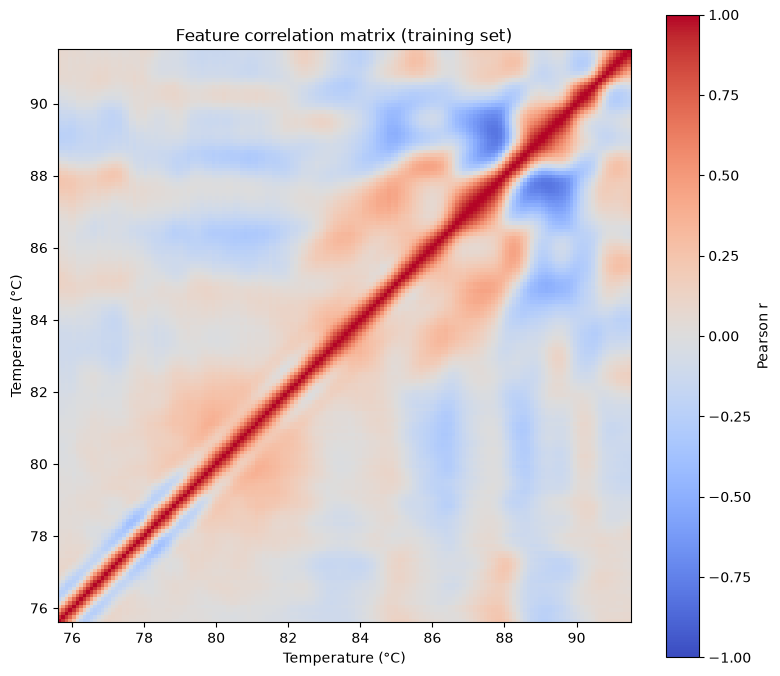

In [17]:
temps = X_train.columns.astype(float)
corr = X_train.corr()   # Pearson, 160 x 160, training set only

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    corr, cmap="coolwarm", vmin=-1, vmax=1, origin="lower",
    extent=[temps.min(), temps.max(), temps.min(), temps.max()]
)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Feature correlation matrix (training set)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.feature_selection import f_classif

# 1) Relevance: ANOVA F-score of each feature vs species label (training set only)
f_scores, _ = f_classif(X_train, y_train)
relevance = pd.Series(f_scores, index=X_train.columns).fillna(0).sort_values(ascending=False)

# 2) Redundancy control: skip features too correlated with ones already chosen
corr_threshold = 0.80   # adjust if you like
selected = []
for feat in relevance.index:
    if all(abs(corr.loc[feat, s]) < corr_threshold for s in selected):
        selected.append(feat)
    if len(selected) == 5:
        break

if len(selected) < 5:
    print("Warning: fewer than 5 features passed the threshold; raise corr_threshold.")

print("Naive top 5 by F-score (°C):        ", list(relevance.index[:5]))
print("Top 5 after redundancy filter (°C):", selected)

print("\nF-scores of selected features:")
print(relevance[selected].round(1).to_string())

print("\nCorrelation among selected features:")
print(corr.loc[selected, selected].round(2))

Naive top 5 by F-score (°C):         ['87.5', '87.4', '87.6', '87.3', '87.7']
Top 5 after redundancy filter (°C): ['87.5', '87.9', '89.2', '87.0', '89.6']

F-scores of selected features:
87.5    20349.6
87.9     8871.8
89.2     7651.5
87.0     6722.5
89.6     5833.7

Correlation among selected features:
      87.5  87.9  89.2  87.0  89.6
87.5  1.00  0.70 -0.73  0.75 -0.71
87.9  0.70  1.00 -0.77  0.25 -0.70
89.2 -0.73 -0.77  1.00 -0.46  0.78
87.0  0.75  0.25 -0.46  1.00 -0.54
89.6 -0.71 -0.70  0.78 -0.54  1.00


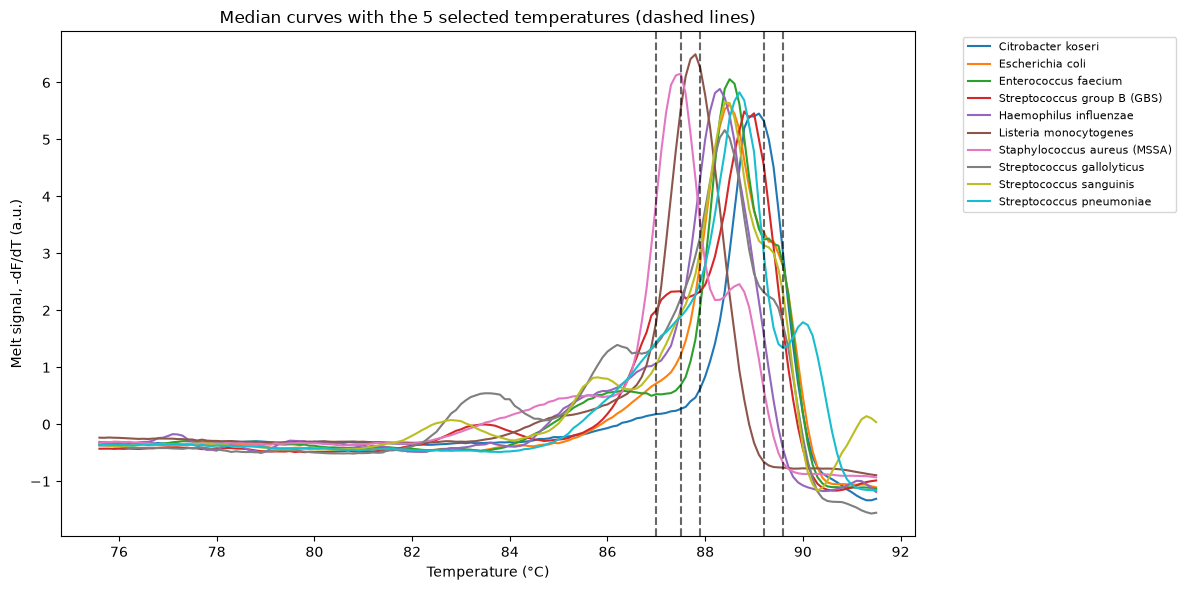

In [19]:
# Where the selected temperatures sit on the melt curves
plt.figure(figsize=(12, 6))

for label in range(10):
    plt.plot(
        temps,
        X_train[y_train == label].median(axis=0),
        label=species_names[label]
    )

for s in selected:
    plt.axvline(float(s), color="black", linestyle="--", alpha=0.6)

plt.xlabel("Temperature (°C)")
plt.ylabel("Melt signal, -dF/dT (a.u.)")
plt.title("Median curves with the 5 selected temperatures (dashed lines)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 12. Retrain on the top-5 features and show the loss
The loss used is **log loss** (cross-entropy); lower is better.

A Random Forest has no iterative training loss, so two views are shown:
- **Random Forest, loss vs number of trees.** The training loss is measured on samples the trees were fitted to, so it is naturally close to zero. A gap between train and test is therefore expected and is not by itself a sign of a problem.
- **Gradient boosting on the same 5 features.** This model minimises log loss step by step, so it gives a conventional training/test loss curve.

In [20]:
from sklearn.metrics import log_loss

X_train5, X_test5 = X_train[selected], X_test[selected]

rf5 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf5.fit(X_train5, y_train)

print("Random Forest, 5 features")
for name, Xs, ys in [("Train", X_train5, y_train), ("Test ", X_test5, y_test)]:
    proba = rf5.predict_proba(Xs)
    print(f"  {name}: log loss = {log_loss(ys, proba, labels=rf5.classes_):.4f}, "
          f"accuracy = {accuracy_score(ys, rf5.predict(Xs)):.4f}")

print("\nFor reference, Random Forest, all 160 features")
for name, Xs, ys in [("Train", X_train, y_train), ("Test ", X_test, y_test)]:
    proba = model.predict_proba(Xs)
    print(f"  {name}: log loss = {log_loss(ys, proba, labels=model.classes_):.4f}, "
          f"accuracy = {accuracy_score(ys, model.predict(Xs)):.4f}")

Random Forest, 5 features
  Train: log loss = 0.0423, accuracy = 1.0000
  Test : log loss = 0.2173, accuracy = 0.9377

For reference, Random Forest, all 160 features
  Train: log loss = 0.0148, accuracy = 1.0000
  Test : log loss = 0.0468, accuracy = 0.9962


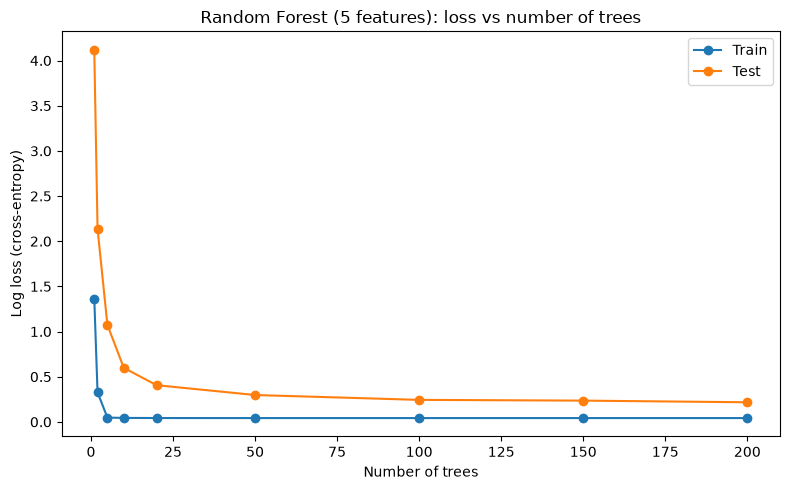

In [21]:
tree_grid = [1, 2, 5, 10, 20, 50, 100, 150, 200]

def loss_by_trees(forest, Xs, ys, grid):
    # log loss of the forest using only its first k trees
    Xv = Xs.to_numpy()
    running = np.zeros((len(Xv), len(forest.classes_)))
    out = []
    for k, tree in enumerate(forest.estimators_, start=1):
        running += tree.predict_proba(Xv)
        if k in grid:
            out.append(log_loss(ys, running / k, labels=forest.classes_))
    return out

train_loss = loss_by_trees(rf5, X_train5, y_train, tree_grid)
test_loss = loss_by_trees(rf5, X_test5, y_test, tree_grid)

plt.figure(figsize=(8, 5))
plt.plot(tree_grid, train_loss, marker="o", label="Train")
plt.plot(tree_grid, test_loss, marker="o", label="Test")
plt.xlabel("Number of trees")
plt.ylabel("Log loss (cross-entropy)")
plt.title("Random Forest (5 features): loss vs number of trees")
plt.legend()
plt.tight_layout()
plt.show()

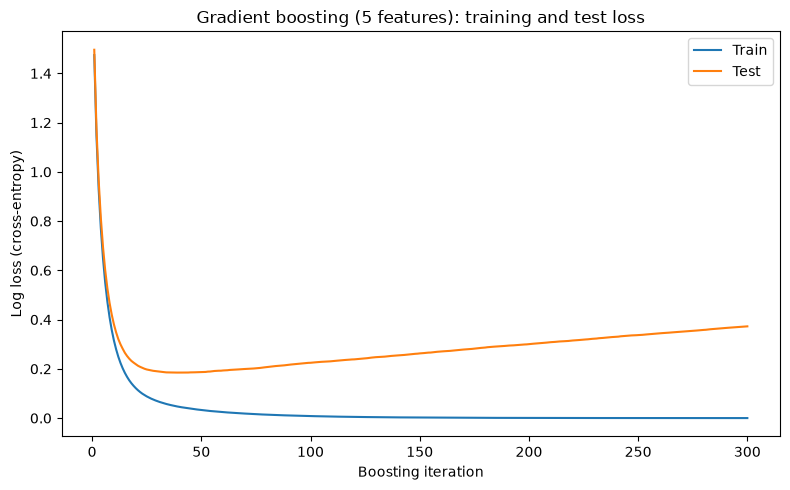

Final train log loss: 0.0001
Final test log loss:  0.3726
Test accuracy:        0.9382
Lowest test loss 0.1844 at iteration 38 (descriptive only; do not tune on the test set)


In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.1, early_stopping=False, random_state=42
)
hgb.fit(X_train5, y_train)

hgb_train = [log_loss(y_train, p, labels=hgb.classes_) for p in hgb.staged_predict_proba(X_train5)]
hgb_test = [log_loss(y_test, p, labels=hgb.classes_) for p in hgb.staged_predict_proba(X_test5)]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(hgb_train) + 1), hgb_train, label="Train")
plt.plot(range(1, len(hgb_test) + 1), hgb_test, label="Test")
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss (cross-entropy)")
plt.title("Gradient boosting (5 features): training and test loss")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train log loss: {hgb_train[-1]:.4f}")
print(f"Final test log loss:  {hgb_test[-1]:.4f}")
print(f"Test accuracy:        {accuracy_score(y_test, hgb.predict(X_test5)):.4f}")
print(f"Lowest test loss {min(hgb_test):.4f} at iteration {int(np.argmin(hgb_test)) + 1} (descriptive only; do not tune on the test set)")

## 13. What this result does and does not show
- **Held-out performance within this dataset:** the test curves were not used for training, so this is not classic overfitting. Exact duplicate curves were ruled out in section 6.
- **Confounding with chip/run:** per the dataset paper, each species' curves come from a single chip, so a model could partly rely on chip-specific noise or temperature shifts instead of species-specific melt shape. A random curve-level split puts curves from the same chip in both train and test, and a leave-one-chip-out split is impossible because each chip is one class.
- **Not tested:** new chips, instruments, dyes, primers or labs. Accuracy on such data may be lower, and should be measured on an independent dataset before drawing conclusions about real-world use.
- **Context:** the original paper reports accuracy above 99.5% for four classifiers on this dataset (five train/test splits), so the score here is in line with that benchmark rather than unusual.

## 14. Save model (optional)
The pickle is large, so keep it out of git (see `.gitignore`).

In [13]:
import joblib

joblib.dump(model, "hrm_random_forest.pkl")
print("Model saved successfully!")

Model saved successfully!
